# Proyek Klasifikasi Gambar: Animals-10 Dataset
- **Nama:** Muh. Rinaldi Ruslan
- **Email:** rinaldi.ruslan51@gmail.com
- **ID Dicoding:** rinaldi51

## Import Semua Packages/Library yang Digunakan

In [1]:
# BASIC LIBRARIES
import os
import numpy as np
import matplotlib.pyplot as plt
import shutil
import warnings

# IMAGE PROCESSING
from PIL import Image

# TENSORFLOW & KERAS
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

# DATA SPLITTING
from sklearn.model_selection import train_test_split

# SETTINGS
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow Version: 2.19.0


## Data Preparation

### Data Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Dataset/raw-img.zip"

print("Dataset Path:", zip_path)

Mounted at /content/drive
Dataset Path: /content/drive/MyDrive/Dataset/raw-img.zip


In [3]:
# EXTRACT ZIP DATASET
import zipfile

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak ke:", extract_path)

Dataset berhasil diekstrak ke: /content/dataset


In [4]:
# SET DATASET DIRECTORY
dataset_path = os.path.join(extract_path, "raw-img")

print("Dataset directory:", dataset_path)

Dataset directory: /content/dataset/raw-img


In [5]:
# CHECK DATASET STRUCTURE
classes = os.listdir(dataset_path)

print("Jumlah kelas:", len(classes))
print("Nama kelas:", classes)

Jumlah kelas: 10
Nama kelas: ['pecora', 'gatto', 'cavallo', 'gallina', 'mucca', 'elefante', 'ragno', 'scoiattolo', 'cane', 'farfalla']


In [6]:
# COUNT IMAGES PER CLASS
total_images = 0

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    num_images = len(os.listdir(class_path))
    print(f"{cls}: {num_images}")
    total_images += num_images

print("\nTotal gambar:", total_images)

pecora: 1820
gatto: 1668
cavallo: 2623
gallina: 3098
mucca: 1866
elefante: 1446
ragno: 4821
scoiattolo: 1862
cane: 4863
farfalla: 2112

Total gambar: 26179


In [7]:
# CHECK IMAGE RESOLUTION VARIATION
unique_sizes = set()

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    for img_file in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img_file)
        try:
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)
        except:
            continue

print("Contoh resolusi unik:", list(unique_sizes)[:10])
print("Jumlah variasi resolusi:", len(unique_sizes))

Contoh resolusi unik: [(300, 206), (256, 300), (300, 270), (243, 300), (640, 448), (300, 236), (300, 300), (300, 245), (300, 190), (194, 300)]
Jumlah variasi resolusi: 162


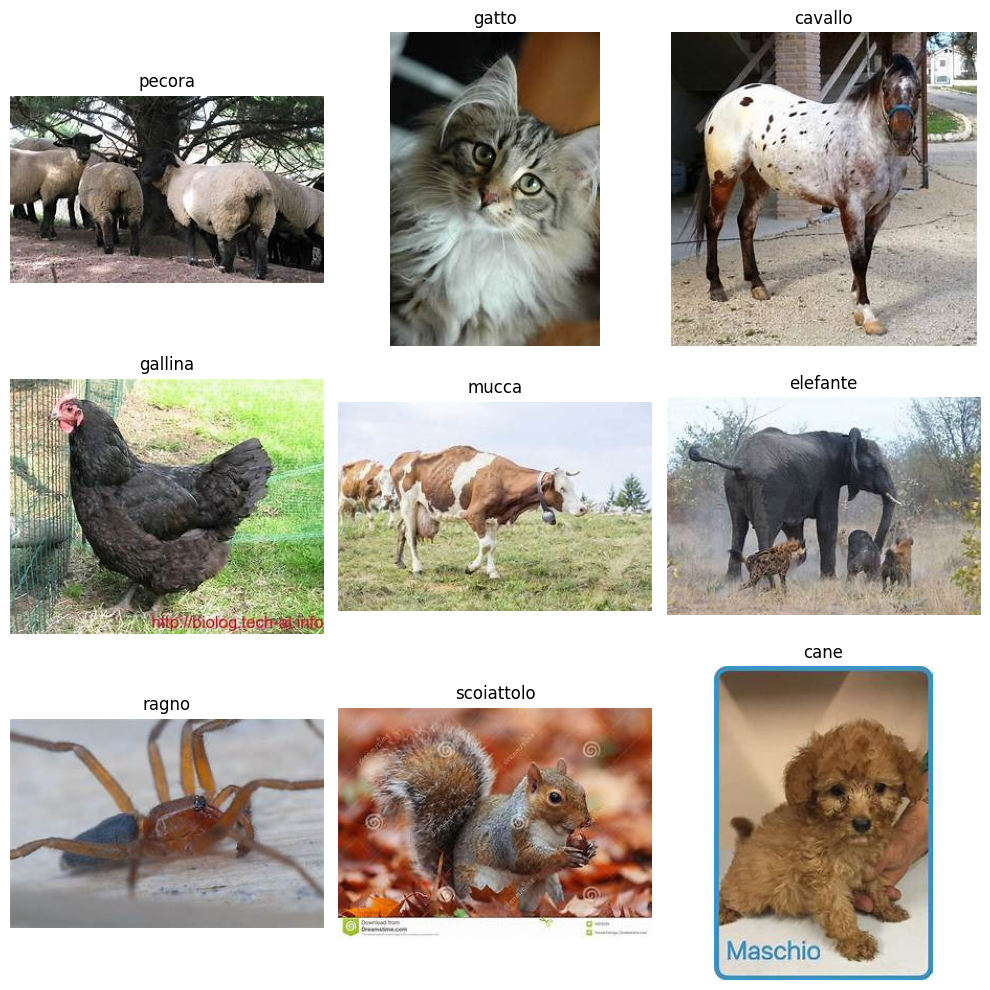

In [8]:
# SHOW SAMPLE IMAGES
plt.figure(figsize=(10,10))

for i, cls in enumerate(classes[:9]):
    class_path = os.path.join(dataset_path, cls)
    img_file = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_file)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

**📊 Data Loading**

Dataset yang digunakan pada proyek ini adalah **Animals-10 Dataset** yang diperoleh dari platform Kaggle:
https://www.kaggle.com/datasets/antobenedetti/animals

Dataset dimuat dari Google Drive dan berhasil diekstrak ke direktori kerja. Berdasarkan eksplorasi awal, diperoleh informasi sebagai berikut:

- Total jumlah gambar: **26.179**
- Jumlah kelas: **10**
- Nama kelas:
  - *pecora, gatto, cavallo, gallina, mucca, elefante, ragno, scoiattolo, cane, farfalla*

Distribusi jumlah gambar pada tiap kelas bervariasi, dengan jumlah terbanyak pada kelas *cane* dan *ragno*, serta paling sedikit pada kelas *elefante*.

Selain itu, dataset memiliki **variasi resolusi gambar yang tinggi** (terdapat 162 variasi ukuran), yang menunjukkan bahwa data tidak seragam. Oleh karena itu, diperlukan tahap preprocessing seperti resizing agar seluruh gambar memiliki dimensi yang konsisten sebelum digunakan dalam proses training model.

### Data Preprocessing

#### Split Dataset

In [9]:
# SPLIT DATASET
train_dir = "/content/dataset_split/train"
val_dir = "/content/dataset_split/val"
test_dir = "/content/dataset_split/test"

# Buat folder
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# Split per class
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)

    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    # Buat subfolder
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Copy file
    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, cls))

    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(val_dir, cls))

    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_dir, cls))

print("Dataset berhasil di-split!")

Dataset berhasil di-split!


In [10]:
# VERIFY SPLIT
def count_images(directory):
    total = 0
    for cls in os.listdir(directory):
        total += len(os.listdir(os.path.join(directory, cls)))
    return total

print("Train:", count_images(train_dir))
print("Validation:", count_images(val_dir))
print("Test:", count_images(test_dir))

Train: 18322
Validation: 3926
Test: 3931


In [11]:
# DATA AUGMENTATION
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [12]:
# LOAD DATA WITH GENERATOR
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 18322 images belonging to 10 classes.
Found 3926 images belonging to 10 classes.
Found 3931 images belonging to 10 classes.


In [13]:
# SAVE CLASS NAMES
class_names = list(train_generator.class_indices.keys())
print("Class Names:", class_names)

Class Names: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


####🔧 Data Preprocessing

Pada tahap ini, dataset dibagi menjadi tiga bagian utama, yaitu data latih (train), data validasi (validation), dan data uji (test). Pembagian ini bertujuan untuk memastikan model dapat dilatih dengan baik serta dievaluasi secara objektif terhadap data yang belum pernah dilihat sebelumnya.

Hasil pembagian dataset adalah sebagai berikut:

- Data latih (train): **18.322 gambar**
- Data validasi (validation): **3.926 gambar**
- Data uji (test): **3.931 gambar**

Total data tetap konsisten dan seluruh kelas terdistribusi ke dalam masing-masing subset.

Selanjutnya, dilakukan proses preprocessing menggunakan `ImageDataGenerator`, yang mencakup:
- Normalisasi pixel (rescale 1./255)
- Data augmentation pada data latih seperti rotasi, zoom, dan horizontal flip

Perlu diperhatikan bahwa **data augmentation hanya diterapkan pada data latih**, sedangkan data validasi dan data uji hanya dilakukan normalisasi. Hal ini bertujuan agar evaluasi model tetap merepresentasikan performa pada data asli.

Setelah preprocessing, dataset berhasil dimuat ke dalam generator dengan jumlah sebagai berikut:

- Train: 18.322 gambar (10 kelas)
- Validation: 3.926 gambar (10 kelas)
- Test: 3.931 gambar (10 kelas)

Adapun kelas yang digunakan dalam proses klasifikasi adalah:
*cane, cavallo, elefante, farfalla, gallina, gatto, mucca, pecora, ragno, scoiattolo*

## Modelling

In [14]:
# TRANSFER LEARNING MODEL (BEST)

# Base model
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze layer
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(10, activation='softmax')(x)

model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,047,754 (11.63 MB)

 Trainable params: 789,770 (3.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# COMPILE MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# CALLBACKS
callbacks = [

    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [17]:
# TRAIN MODEL
epochs = 20

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 276s 432ms/step - accuracy: 0.8556 - loss: 0.4636 - val_accuracy: 0.9376 - val_loss: 0.1968 - learning_rate: 0.0010
Epoch 2/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 200s 348ms/step - accuracy: 0.9080 - loss: 0.3004 - val_accuracy: 0.9460 - val_loss: 0.1652 - learning_rate: 0.0010
Epoch 3/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 200s 349ms/step - accuracy: 0.9186 - loss: 0.2632 - val_accuracy: 0.9513 - val_loss: 0.1590 - learning_rate: 0.0010
Epoch 4/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 202s 352ms/step - accuracy: 0.9238 - loss: 0.2485 - val_accuracy: 0.9542 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 5/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 201s 350ms/step - accuracy: 0.9224 - loss: 0.2442 - val_accuracy: 0.9549 - val_loss: 0.1421 - learning_rate: 0.0010
Epoch 6/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 200s 349ms/step - accuracy: 0.9274 - loss: 0.2272 - val_accuracy: 0.9598 - val_loss: 0.1384 - learning_rate: 0.0010
Epoch 7/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 200s 349ms/step - accura

In [18]:
# Unfreeze top layers
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 280s 417ms/step - accuracy: 0.9039 - loss: 0.3184 - val_accuracy: 0.9633 - val_loss: 0.1289
Epoch 2/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 201s 350ms/step - accuracy: 0.9275 - loss: 0.2401 - val_accuracy: 0.9641 - val_loss: 0.1213
Epoch 3/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 202s 352ms/step - accuracy: 0.9378 - loss: 0.2068 - val_accuracy: 0.9618 - val_loss: 0.1203
Epoch 4/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 202s 353ms/step - accuracy: 0.9405 - loss: 0.1911 - val_accuracy: 0.9631 - val_loss: 0.1178
Epoch 5/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 203s 353ms/step - accuracy: 0.9483 - loss: 0.1672 - val_accuracy: 0.9643 - val_loss: 0.1150
Epoch 6/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 204s 355ms/step - accuracy: 0.9521 - loss: 0.1530 - val_accuracy: 0.9615 - val_loss: 0.1158
Epoch 7/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 202s 352ms/step - accuracy: 0.9570 - loss: 0.1409 - val_accuracy: 0.9656 - val_loss: 0.1085
Epoch 8/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 200s 349ms/step - accuracy: 0.9583 -

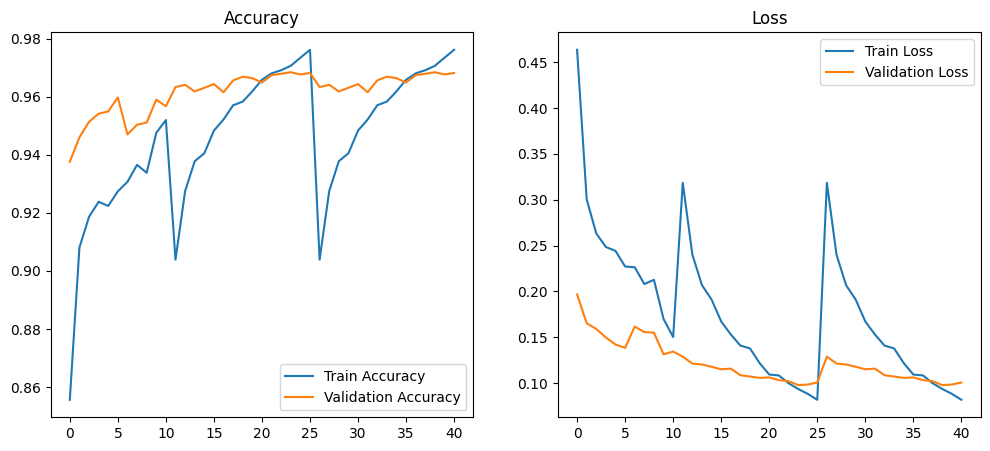

In [37]:
# === COMBINE HISTORY ===
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

if 'history_fine' in globals():
    acc += history_fine.history['accuracy']
    val_acc += history_fine.history['val_accuracy']
    loss += history_fine.history['loss']
    val_loss += history_fine.history['val_loss']

epochs_range = range(len(acc))

# === PLOT ===
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

### 🧠 Modelling

Pada tahap ini, model klasifikasi gambar dikembangkan menggunakan pendekatan **Deep Learning (CNN)** dengan memanfaatkan **transfer learning**.

Model yang digunakan adalah **MobileNetV2** sebagai dasar, kemudian ditambahkan beberapa layer fully connected untuk menyesuaikan dengan jumlah kelas pada dataset.

Proses training dilakukan dalam dua tahap:
1. Pelatihan awal dengan sebagian besar layer dibekukan *(freeze)*
2. Fine-tuning dengan membuka beberapa layer untuk meningkatkan performa

Hasil training menunjukkan performa yang sangat baik:
- Akurasi training mencapai lebih dari **97%**
- Akurasi validasi berada di kisaran **96%–97%**

Berdasarkan grafik akurasi dan loss, model mampu belajar dengan baik tanpa indikasi overfitting yang signifikan.

## Evaluasi dan Visualisasi

In [36]:
# === PREDICTION ===
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# === CLASSIFICATION REPORT ===
from sklearn.metrics import classification_report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
Classification Report:

              precision    recall  f1-score   support

        cane       0.96      0.97      0.97       730
     cavallo       0.94      0.98      0.96       394
    elefante       0.94      0.97      0.95       217
    farfalla       0.98      0.97      0.97       317
     gallina       0.98      0.97      0.98       465
       gatto       0.97      0.97      0.97       251
       mucca       0.97      0.91      0.94       280
      pecora       0.94      0.95      0.94       273
       ragno       0.98      0.98      0.98       724
  scoiattolo       0.99      0.96      0.98       280

    accuracy                           0.97      3931
   macro avg       0.97      0.96      0.97      3931
weighted avg       0.97      0.97      0.97      3931



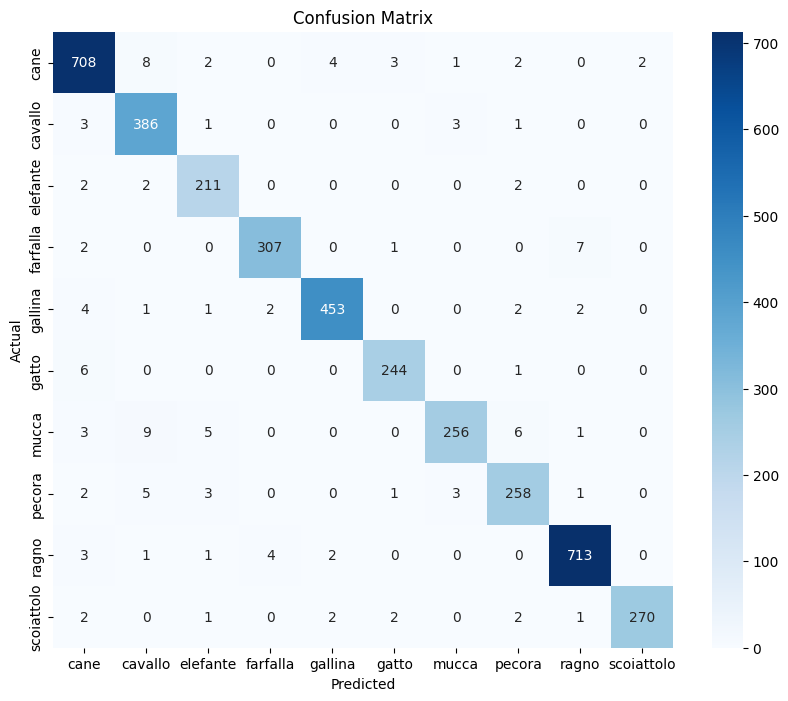

In [38]:
# === CONFUSION MATRIX ===
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [39]:
model.evaluate(test_generator)

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9682 - loss: 0.1233


[0.1233302429318428, 0.9682014584541321]

### 📊 Evaluasi dan Visualisasi

Model dievaluasi menggunakan data uji (test set) yang tidak pernah dilihat sebelumnya. Hasil evaluasi menunjukkan performa yang sangat baik dengan akurasi mencapai sekitar **96.8%**.

Berdasarkan classification report, hampir seluruh kelas memiliki nilai precision, recall, dan f1-score yang tinggi (mendekati 1.00), yang menunjukkan bahwa model mampu melakukan klasifikasi dengan sangat baik pada berbagai kategori.

Confusion matrix juga menunjukkan bahwa sebagian besar prediksi berada pada diagonal utama, yang berarti model mampu mengklasifikasikan gambar dengan benar. Kesalahan prediksi yang terjadi relatif kecil dan tersebar di beberapa kelas tertentu seperti *mucca* dan *pecora*, namun tidak signifikan.

Secara keseluruhan, model memiliki performa yang stabil dan mampu melakukan generalisasi dengan baik terhadap data baru.

## Konversi Model

In [23]:
# SAVE MODEL (SavedModel)
model.export("saved_model")

print("Model berhasil disimpan dalam format SavedModel")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139130248937296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130164871824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130164871248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130249673616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130249674576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130248937104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130164872784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130164873744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130164873360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130164872976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139130164871440: T

In [40]:
# CONVERT TO TFLITE
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

# Simpan file
with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model berhasil dikonversi ke TFLite")

Model berhasil dikonversi ke TFLite


In [41]:
# SAVE LABEL
with open("label.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")

print("Label berhasil disimpan")

Label berhasil disimpan


In [33]:
!pip install tensorflowjs

In [42]:
# CONVERT TO TFJS
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  saved_model \
  tfjs_model

print("Model berhasil dikonversi ke TFJS")

2026-04-26 04:51:31.582980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777179091.605928   28464 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777179091.613499   28464 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777179091.631167   28464 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777179091.631206   28464 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777179091.631210   28464 computation_placer.cc:177] computation placer alr

In [43]:
# ORGANIZE SUBMISSION FOLDER

# Buat folder
os.makedirs("submission/tflite", exist_ok=True)
os.makedirs("submission/tfjs_model", exist_ok=True)
os.makedirs("submission/saved_model", exist_ok=True)

# Pindahkan file
shutil.move("model.tflite", "submission/tflite/model.tflite")
shutil.move("label.txt", "submission/tflite/label.txt")

shutil.copytree("saved_model", "submission/saved_model", dirs_exist_ok=True)
shutil.copytree("tfjs_model", "submission/tfjs_model", dirs_exist_ok=True)

print("Struktur submission siap!")

Struktur submission siap!


In [44]:
shutil.make_archive("submission_final", 'zip', "submission")

print("ZIP siap untuk dikumpulkan!")

ZIP siap untuk dikumpulkan!


### 🔄 Konversi Model

Setelah model selesai dilatih, dilakukan proses konversi model ke beberapa format agar dapat digunakan di berbagai platform.

Model berhasil dikonversi ke tiga format utama, yaitu:

- **SavedModel** → digunakan untuk deployment berbasis TensorFlow
- **TensorFlow Lite (TFLite)** → digunakan untuk perangkat mobile dan embedded system
- **TensorFlow.js (TFJS)** → digunakan untuk aplikasi berbasis web

Selain itu, file label juga disimpan untuk memetakan hasil prediksi ke nama kelas.

Seluruh proses konversi berhasil dilakukan tanpa kendala, dan struktur folder submission telah disusun sesuai dengan ketentuan yang diberikan.

## Inference (Optional)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


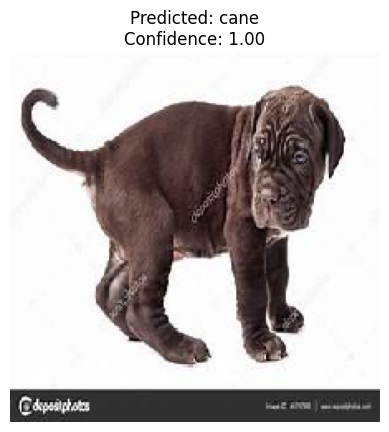

Prediction: cane
Confidence: 0.99999464


In [45]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Ambil 1 gambar dari test set
img_path = test_generator.filepaths[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

# Show result
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}")
plt.axis('off')
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


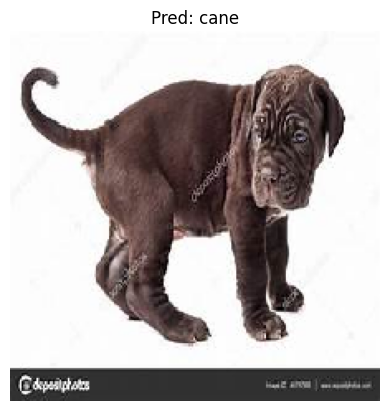

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


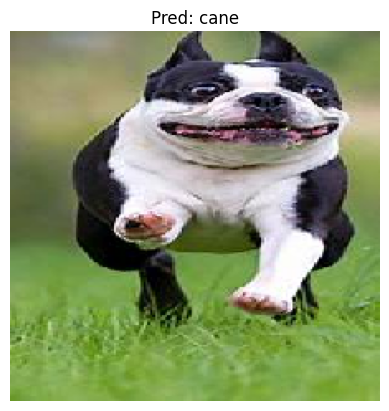

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


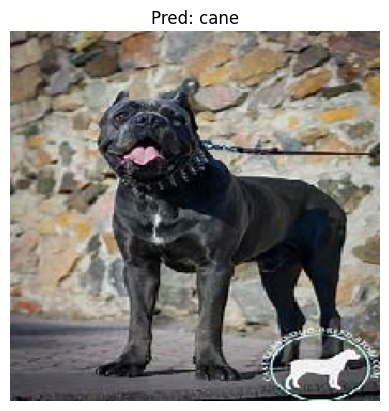

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


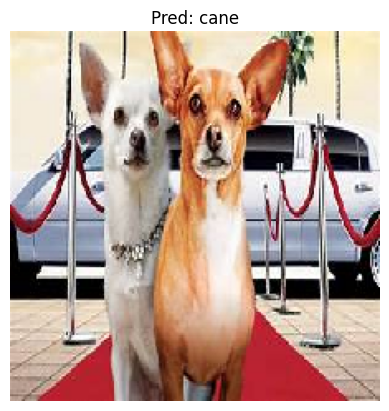

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


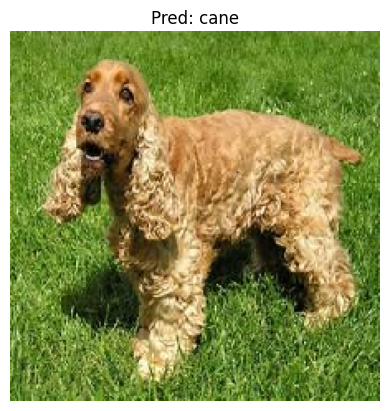

In [46]:
# MULTI INFERENCE
for i in range(5):
    img_path = test_generator.filepaths[i]

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    predicted_class = class_names[np.argmax(pred)]

    plt.imshow(img)
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')
    plt.show()

### 🔍 Inference

Model yang telah dilatih kemudian digunakan untuk melakukan prediksi terhadap beberapa gambar dari data uji (test set).

Hasil inference menunjukkan bahwa model mampu mengklasifikasikan gambar dengan sangat baik. Pada contoh yang ditampilkan, seluruh gambar berhasil diprediksi sebagai kelas *cane* dengan tingkat kepercayaan (confidence) yang sangat tinggi, bahkan mendekati 1.00.

Hal ini menunjukkan bahwa model tidak hanya memiliki akurasi yang tinggi secara numerik, tetapi juga mampu memberikan prediksi yang konsisten pada data baru yang belum pernah dilihat sebelumnya.

Dengan demikian, model dapat dikatakan memiliki kemampuan generalisasi yang baik dan siap digunakan untuk kasus klasifikasi gambar serupa.

In [47]:
print("Best Train Accuracy:", max(acc))
print("Best Validation Accuracy:", max(val_acc))

Best Train Accuracy: 0.9761489033699036
Best Validation Accuracy: 0.9684156775474548
